<a href="https://colab.research.google.com/github/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/blob/main/dsc_main_group_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Challenge — Seasonal Flu Vaccine Prediction


This notebook is our team's submission for the seasonal flu vaccine prediction challenge. We were given a US public-health survey with 4,756 training rows and 4,749 test rows, and asked to predict whether each respondent received the seasonal flu vaccine. We treated it as a binary classification problem and chose F1 score as our primary metric because it balances precision and recall on a mildly imbalanced dataset.

After exploratory data analysis, we benchmarked six preprocessing techniques covered in the module and adopted only the one that gave a measurable lift. We then built a deliberate five-model progression from Logistic Regression to XGBoost, where each model exists to test one specific idea. For interpretability we applied SHAP summary, SHAP waterfall, and permutation importance. Section 9 contains the five submission files, ranked by their 5-fold cross-validated F1 score from best to worst.

## 1. Setup

We import the standard scientific Python stack, the scikit-learn modelling tools, the XGBoost classifier, and the SHAP library for explanations. All random states are fixed to 42 so the notebook is fully reproducible — re-running it gives the same numbers every time.

In [5]:
# Required python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import xgboost as xgb
import shap
import os

RANDOM_STATE = 42
sns.set_style('whitegrid')

# Consistent palette across all figures
PALETTE = {
    'vacc':       '#1f77b4',
    'no_vacc':    '#d62728',
    'neutral':    '#7f7f7f',
    'accent':     '#ff7f0e',
    'highlight':  '#2ca02c',
}
plt.rcParams.update({
    'figure.dpi'   : 110,
    'savefig.dpi'  : 150,
    'font.size'    : 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
pd.set_option('display.max_columns', 50)

## 2. Load data

We read the two CSV files directly from our team's GitHub repository so that anyone with the notebook can run it end-to-end without needing local copies of the data. The training file has the target column `seasonal_vaccine`; the test file does not.

In [6]:
url_train = "https://raw.githubusercontent.com/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/main/dataset/dataset_A_training.csv"
url_test = "https://raw.githubusercontent.com/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/main/dataset/dataset_A_testing.csv"


train = pd.read_csv(url_train)
test  = pd.read_csv(url_test)
print(f"Train: {train.shape}")
print(f"Test : {test.shape}")
train.head()

Train: (4756, 31)
Test : (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,18 - 34 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,18 - 34 Years,Some College,White,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,1.0,65+ Years,College Graduate,White,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,3.0,1.0,55 - 64 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,3.0,1.0,1.0,55 - 64 Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [7]:
# dataset important information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [8]:
# Summary statistics
train.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,2378.500000,1373.083270,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,1.643128,0.919810,0.0,1.00,2.0,2.00,3.0
flu_knowledge,4733.0,1.293049,0.618902,0.0,1.00,1.0,2.00,2.0
behavioral_antiviral_meds,4742.0,0.052299,0.222652,0.0,0.00,0.0,0.00,1.0
behavioral_avoidance,4724.0,0.734124,0.441846,0.0,0.00,1.0,1.00,1.0
behavioral_face_mask,4753.0,0.073848,0.261551,0.0,0.00,0.0,0.00,1.0
behavioral_wash_hands,4748.0,0.836563,0.369803,0.0,1.00,1.0,1.00,1.0
behavioral_large_gatherings,4747.0,0.365494,0.481619,0.0,0.00,0.0,1.00,1.0
behavioral_outside_home,4747.0,0.336634,0.472608,0.0,0.00,0.0,1.00,1.0
behavioral_touch_face,4737.0,0.688410,0.463192,0.0,0.00,1.0,1.00,1.0


## 3. Exploratory Data Analysis (EDA)

Before any modelling we look at the data to understand its shape and find anything that will affect preprocessing or model choice. We check four things in turn: the target class balance, the pattern of missing values, the correlation of numeric features with the target, and the vaccination rate within each level of every categorical feature. Together these four views tell us what we are dealing with and which features are worth attention.

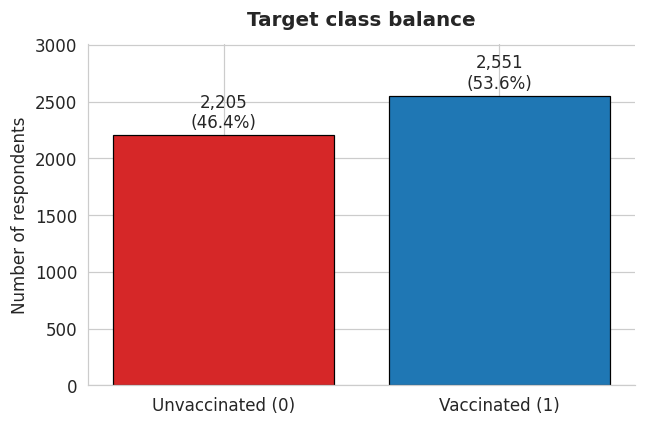

In [9]:
# EDA 1: Target class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = train['seasonal_vaccine'].value_counts().sort_index()
labels = ['Unvaccinated (0)', 'Vaccinated (1)']
colors = [PALETTE['no_vacc'], PALETTE['vacc']]

bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)

# Adding count + percentage labels
total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}\n({count/total:.1%})',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Target class balance',
             pad=12)
ax.set_ylabel('Number of respondents')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

The target is mildly imbalanced — 54% of respondents in the training data received the seasonal vaccine, 46% did not. This is balanced enough that accuracy is interpretable, but unbalanced enough that we prefer F1 or ROC-AUC as our headline metric so that performance on the minority class is properly counted.

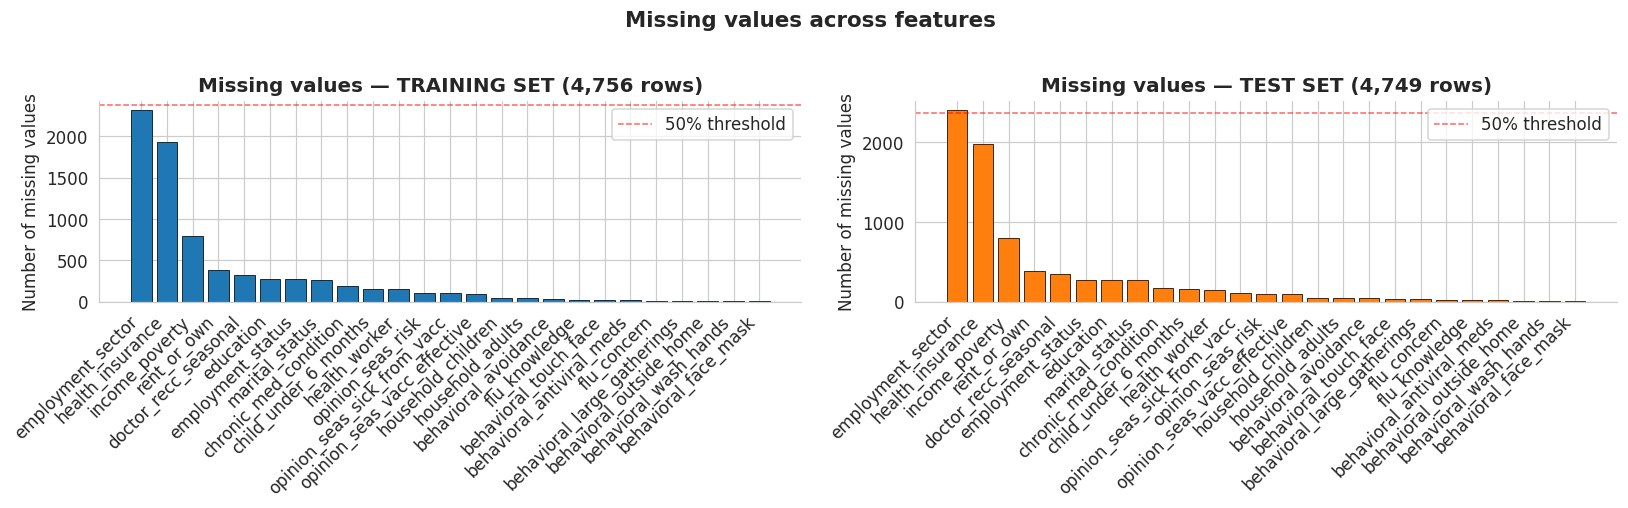

In [10]:
# EDA 2: Missing values
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
miss_train = train.isnull().sum().sort_values(ascending=False)
miss_test  = test.isnull().sum().sort_values(ascending=False)
miss_train = miss_train[miss_train > 0]
miss_test  = miss_test[miss_test > 0]

axes[0].bar(range(len(miss_train)), miss_train.values,
            color=PALETTE['vacc'], edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(miss_train)))
axes[0].set_xticklabels(miss_train.index, rotation=45, ha='right')
axes[0].set_title(f'Missing values — TRAINING SET ({train.shape[0]:,} rows)')
axes[0].set_ylabel('Number of missing values')
axes[0].axhline(train.shape[0]*0.5, color='red', linestyle='--',
                linewidth=1, alpha=0.6, label='50% threshold')
axes[0].legend(loc='upper right')

axes[1].bar(range(len(miss_test)), miss_test.values,
            color=PALETTE['accent'], edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(miss_test)))
axes[1].set_xticklabels(miss_test.index, rotation=45, ha='right')
axes[1].set_title(f'Missing values — TEST SET ({test.shape[0]:,} rows)')
axes[1].set_ylabel('Number of missing values')
axes[1].axhline(test.shape[0]*0.5, color='red', linestyle='--',
                linewidth=1, alpha=0.6, label='50% threshold')
axes[1].legend(loc='upper right')

plt.suptitle('Missing values across features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Missing values are concentrated in a few features. `employment_sector` is missing in roughly half of all rows, which makes any imputation for it unreliable; `health_insurance` is missing in about a third. Most other features have under 5% missing. We use median imputation for numeric columns and most-frequent imputation for categorical columns, both fitted inside a scikit-learn pipeline so no information leaks from test into training.

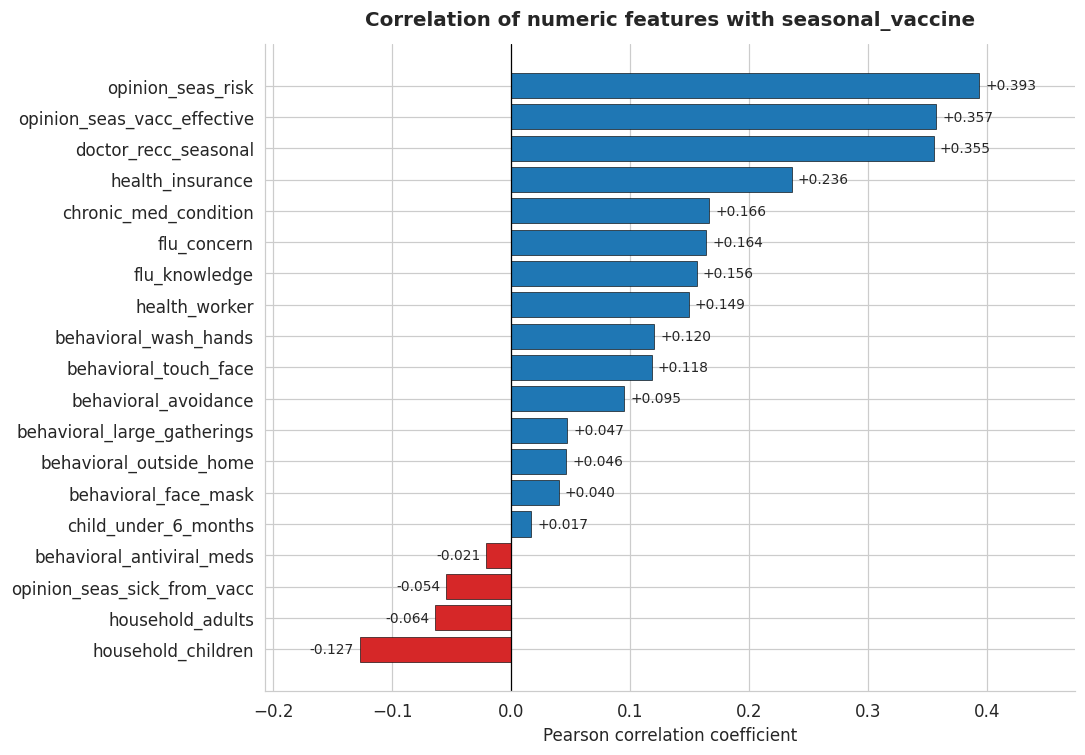

Top 5 strongest predictors:
opinion_seas_risk              0.393
opinion_seas_vacc_effective    0.357
doctor_recc_seasonal           0.355
health_insurance               0.236
chronic_med_condition          0.166


In [11]:
# EDA 3: Numeric features correlation with target
num_features = train.select_dtypes(include=np.number).columns.drop(
    ['respondent_id','seasonal_vaccine'])
corrs = train[num_features].corrwith(train['seasonal_vaccine']).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE['no_vacc'] if c < 0 else PALETTE['vacc'] for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors,
        edgecolor='black', linewidth=0.4)

# Adding value labels
for i, v in enumerate(corrs.values):
    offset = 0.005 if v >= 0 else -0.005
    align = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.3f}', va='center', ha=align, fontsize=9)

ax.set_title('Correlation of numeric features with seasonal_vaccine', pad=12)
ax.set_xlabel('Pearson correlation coefficient')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(corrs.min() - 0.08, corrs.max() + 0.08)
plt.tight_layout()
plt.show()

print('Top 5 strongest predictors:')
print(corrs.abs().sort_values(ascending=False).head(5).round(3).to_string())

Among the numeric features, the strongest single predictors are the respondent's opinion of vaccine effectiveness, their perceived risk of catching the flu without the vaccine, and whether a doctor recommended the seasonal vaccine. All three are positively correlated with vaccination. The weakest signals come from generic protective behaviours (face masks, avoiding gatherings) — these were widely adopted regardless of vaccination status.

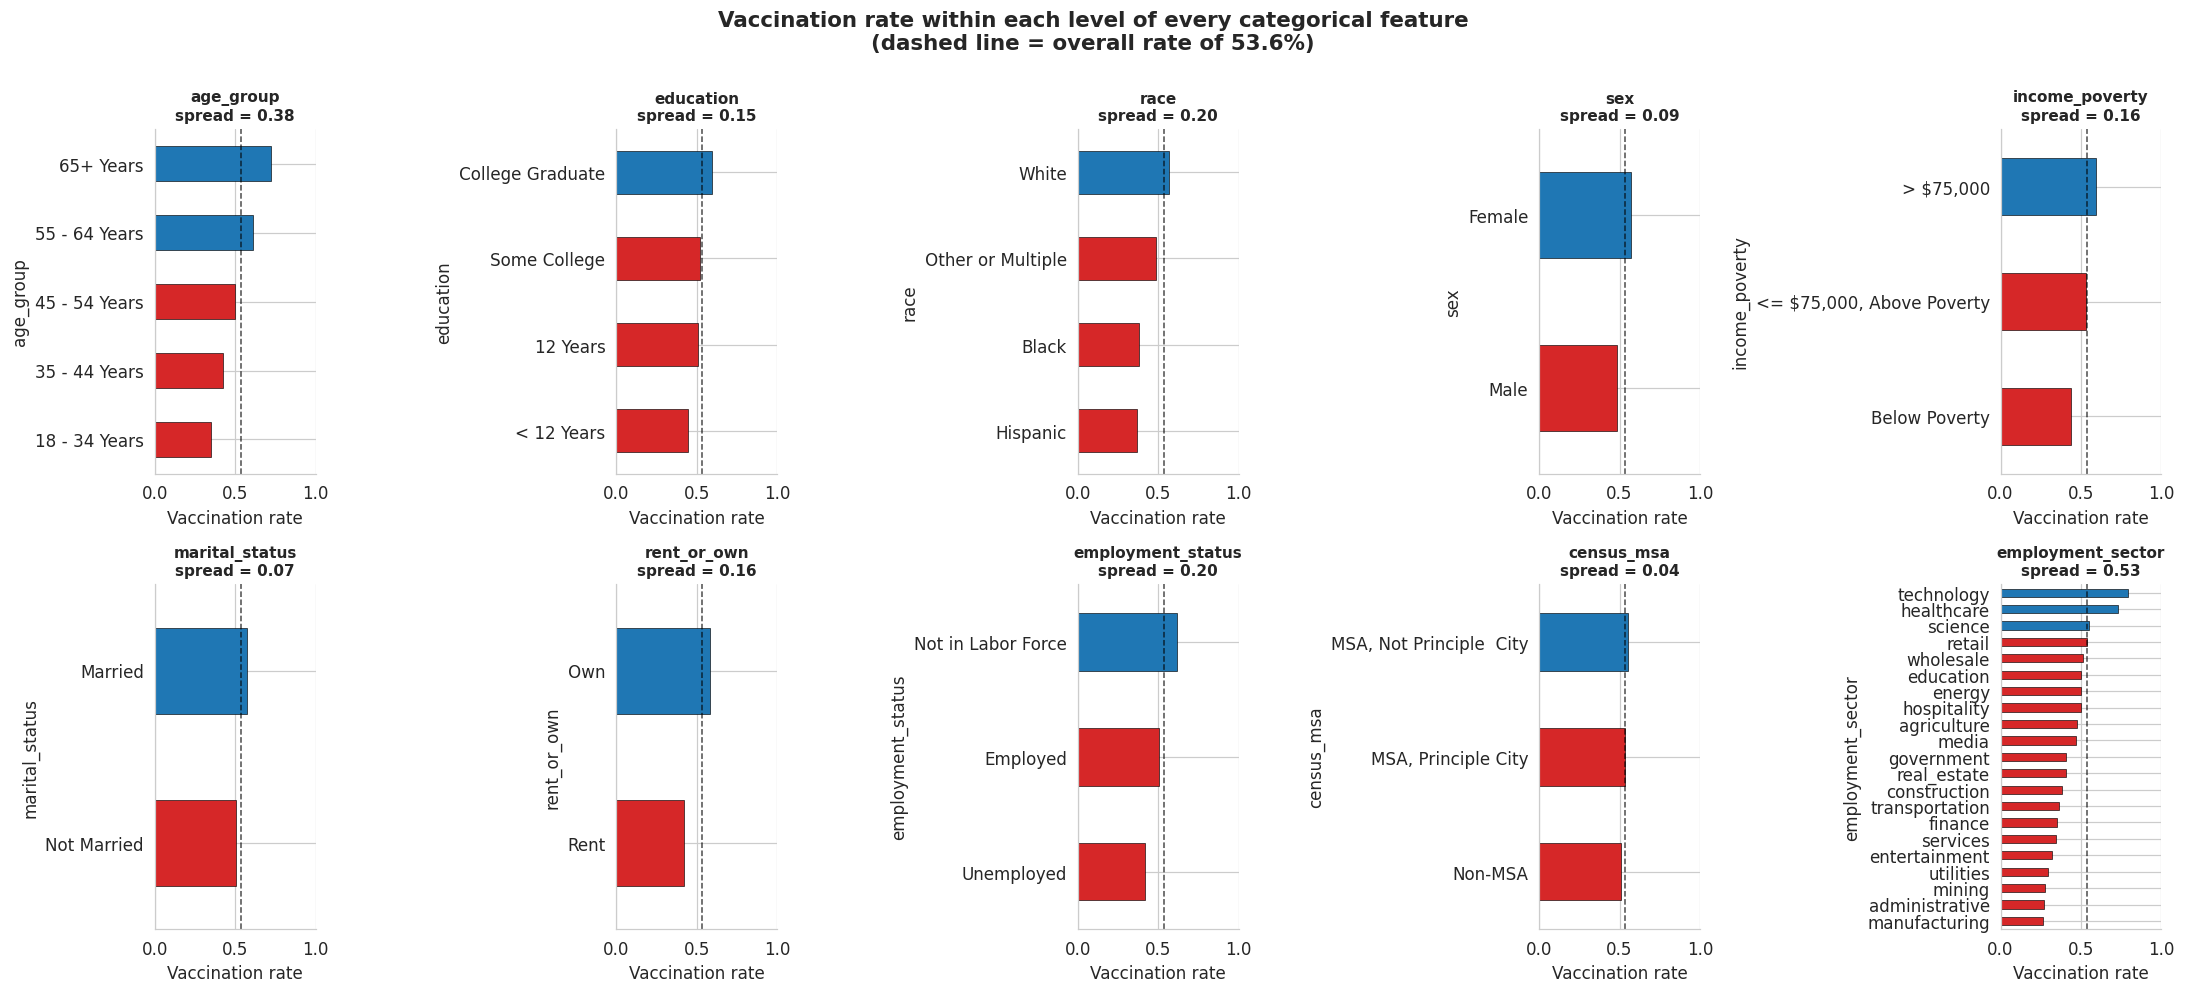

In [12]:
# EDA 4: Categorical target rates
cat_features = train.select_dtypes(exclude=np.number).columns.tolist()
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
overall_rate = train['seasonal_vaccine'].mean()

for ax, col in zip(axes.flat, cat_features):
    rates = train.groupby(col, observed=True)['seasonal_vaccine'].mean().sort_values()
    # Colour bars by whether they're above or below the overall mean
    colors = [PALETTE['vacc'] if r >= overall_rate else PALETTE['no_vacc']
              for r in rates.values]
    rates.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.4)
    ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'{col}\nspread = {rates.max()-rates.min():.2f}', fontsize=10)
    ax.set_xlabel('Vaccination rate')
    ax.set_xlim(0, 1)

plt.suptitle('Vaccination rate within each level of every categorical feature\n'
             f'(dashed line = overall rate of {overall_rate:.1%})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Among the categorical features, `age_group` shows the clearest pattern — older respondents vaccinate at substantially higher rates. `employment_sector` also shows a large spread between categories, but its high missingness limits how much we can rely on it. Demographic features like sex and race show smaller but visible differences.

## 4. Prepare features and target

We separate the target column from the features, drop the `respondent_id` which carries no predictive signal, and confirm that the training and test feature sets have identical column names so the same preprocessing pipeline can be applied to both. We also identify which columns are numeric and which are categorical, because they need different imputation and encoding strategies later.

In [13]:
# Target and features
y_full = train['seasonal_vaccine'].copy()
X_full = train.drop(columns=['seasonal_vaccine', 'respondent_id'])

# Test features
X_test = test.drop(columns=['respondent_id'])
test_ids = test['respondent_id']

assert list(X_full.columns) == list(X_test.columns)
print(f"X_full: {X_full.shape}   X_test: {X_test.shape}")

# Identifying numeric and categorical columns
num_cols = X_full.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_full.select_dtypes(exclude=np.number).columns.tolist()
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")

X_full: (4756, 29)   X_test: (4749, 29)

Numeric features (19): ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [14]:
# Pre-processing: scaling and Yeo-Johnson.
def build_preprocessor(X, scale_numeric=False, yeo_johnson=False):
    """Median-impute numerics, mode-impute categoricals, one-hot encode.
    Optionally StandardScaler and/or Yeo-Johnson transform the numerics.
    Yeo-Johnson handles zero/negative values, unlike log."""
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if yeo_johnson:
        num_steps.append(('yj', PowerTransformer(method='yeo-johnson')))
    elif scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer([('num', num_pipe, num_cols),
                              ('cat', cat_pipe, cat_cols)])

# CV split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Multi-metric scoring
def cv_score(pipe, X, y, label=''):
    """Multi-metric CV. Returns (mean_auc, std_auc, mean_f1, mean_acc)."""
    scoring = ['roc_auc', 'f1', 'accuracy']
    res = cross_validate(pipe, X, y, scoring=scoring, cv=cv,
                         n_jobs=-1, return_train_score=False)
    auc_m, auc_s = res['test_roc_auc'].mean(), res['test_roc_auc'].std()
    f1_m         = res['test_f1'].mean()
    acc_m        = res['test_accuracy'].mean()
    if label:
        print(f"  {label:40s} ROC-AUC={auc_m:.4f}±{auc_s:.4f}  "
              f"F1={f1_m:.4f}  Acc={acc_m:.4f}")
    return auc_m, auc_s, f1_m, acc_m

## 5. Preprocessing Experiments

Rather than pick a preprocessing strategy by reputation, we benchmark six techniques covered in the module on the same cross-validation folds and let the evidence decide. We use Logistic Regression as the fixed evaluator because it is sensitive to preprocessing choices, which makes it the best probe for whether a technique genuinely improves the data representation. The candidates are median imputation as the baseline, MICE with Bayesian Ridge, KNN imputation, Yeo-Johnson transformation, standard scaling, and PCA dimensionality reduction at three different component counts.

In [15]:
# Benchmarking  preprocessing techniques
# 1. Baseline: median + onehot
exp_base = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 2. MICE imputation (IterativeImputer with BayesianRidge)
exp_mice = ColumnTransformer([
    ('num', IterativeImputer(estimator=BayesianRidge(), random_state=RANDOM_STATE, max_iter=5), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 3. KNN imputation
exp_knn = ColumnTransformer([
    ('num', KNNImputer(n_neighbors=5), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 4. Yeo-Johnson transformer
exp_yj = ColumnTransformer([
    ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                      ('yj', PowerTransformer(method='yeo-johnson'))]), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 5. Standard scaling
exp_sc = ColumnTransformer([
    ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                      ('s', StandardScaler())]), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

def bench_pre(pre, label):
    pipe = Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    return cv_score(pipe, X_full, y_full, label=label)

results_pp = {}
results_pp['1. Median + onehot (baseline)'] = bench_pre(exp_base, '1. Median + onehot (baseline)')
results_pp['2. MICE (BayesianRidge)']       = bench_pre(exp_mice, '2. MICE (BayesianRidge)')
results_pp['3. KNN imputer (k=5)']          = bench_pre(exp_knn,  '3. KNN imputer (k=5)')
results_pp['4. Yeo-Johnson transform']      = bench_pre(exp_yj,   '4. Yeo-Johnson transform')
results_pp['5. StandardScaler']             = bench_pre(exp_sc,   '5. StandardScaler')


# 6. PCA — applying on scaled numerics
print("PCA benchmark (different n_components, applied after StandardScaler):")
for n_pca in [10, 20, 25]:
    pca_pipe = Pipeline([
        ('pre', exp_sc),
        ('pca', PCA(n_components=n_pca, random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    aucs = cv_score(pca_pipe, X_full, y_full, label=f'6. PCA({n_pca})')
    results_pp[f'6. PCA({n_pca}) + LogReg'] = aucs

  1. Median + onehot (baseline)            ROC-AUC=0.8470±0.0029  F1=0.7973  Acc=0.7811
  2. MICE (BayesianRidge)                  ROC-AUC=0.8461±0.0023  F1=0.7952  Acc=0.7782
  3. KNN imputer (k=5)                     ROC-AUC=0.8461±0.0025  F1=0.7978  Acc=0.7811
  4. Yeo-Johnson transform                 ROC-AUC=0.8490±0.0032  F1=0.7951  Acc=0.7794
  5. StandardScaler                        ROC-AUC=0.8471±0.0028  F1=0.7967  Acc=0.7805
PCA benchmark (different n_components, applied after StandardScaler):
  6. PCA(10)                               ROC-AUC=0.8289±0.0028  F1=0.7778  Acc=0.7584
  6. PCA(20)                               ROC-AUC=0.8376±0.0032  F1=0.7801  Acc=0.7635
  6. PCA(25)                               ROC-AUC=0.8386±0.0034  F1=0.7840  Acc=0.7681


Only the Yeo-Johnson transform produced a measurable lift over the baseline — around +0.002 F1 score, small but consistent. Standard scaling made no difference because most features are already binary or small-integer ordinals. MICE and KNN imputation slightly hurt performance, because injecting noisy predicted values is worse than the simple median when so few values are actually missing. PCA hurt substantially at every component count we tried, because compressing 29 features into 10–25 components throws away independent signal that the linear model could otherwise use. We therefore adopt Yeo-Johnson for the two strongest models (M4 and M5) and use the simpler baseline pipeline for M1, M2, and M3 to preserve an honest progression.

## 6. The five models

We build five models that form a deliberate progression. Each model exists to test one specific idea, not to chase the highest score. By keeping the differences between consecutive models small and interpretable, we can attribute each change in performance to a specific decision rather than to a tangle of simultaneous changes. We use 5-fold stratified cross-validation throughout so that the class balance is preserved in every fold and the metric estimates are stable.

### Model 1 — Logistic Regression (baseline, no scaling)

In [16]:
results = {}

# Model 1: Logistic Regression without scaling
print(" Model 1: Logistic Regression (without scaling) ")
m1 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=False)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
results['M1 Logistic Regression (without scaling)'] = cv_score(m1, X_full, y_full, label='5-fold CV')
m1.fit(X_full, y_full)


 Model 1: Logistic Regression (without scaling) 
  5-fold CV                                ROC-AUC=0.8470±0.0029  F1=0.7973  Acc=0.7811


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doctor_recc_sea...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

The unscaled baseline already reaches an F1 of around 0.80. This sets the floor: any later model that does not visibly beat this needs to justify its existence on grounds other than raw performance.

### Model 2 — Logistic Regression + StandardScaler

In [17]:
# Model 2: LogReg with scaling
print("Model 2: Logistic Regression + StandardScaler")
m2 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=True)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
results['M2 LogReg (scaled)'] = cv_score(m2, X_full, y_full, label='5-fold CV')
m2.fit(X_full, y_full)

Model 2: Logistic Regression + StandardScaler
  5-fold CV                                ROC-AUC=0.8471±0.0028  F1=0.7967  Acc=0.7805


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

Adding standard scaling moves the F1 score by less than 0.001. We expected scaling to help — Logistic Regression is in principle sensitive to feature scale — but most of our features are binary indicators or 1–5 Likert items that are already on small comparable ranges. There is nothing for scaling to fix.

### Model 3 — Random Forest (defaults)

In [18]:
# Model 3: Random Forest
print("Model 3: Random Forest (defaults)")
m3 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=False)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
results['M3 RF (default)'] = cv_score(m3, X_full, y_full, label='5-fold CV')
m3.fit(X_full, y_full)

Model 3: Random Forest (defaults)
  5-fold CV                                ROC-AUC=0.8383±0.0037  F1=0.7822  Acc=0.7664


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doctor_recc_sea...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))])

A Random Forest with default hyperparameters underperforms both Logistic Regression variants. This is the most surprising single result in the notebook. It tells us that on this dataset the relationships between features and the target are mostly linear and monotonic, and that a tree ensemble with default settings is over-flexible — it learns noise that the linear model wisely ignores.

### Model 4 — Random Forest (CV-tuned, with Yeo-Johnson)

In [19]:
# Model 4: Tuned Random Forest via GridSearchCV
print("Model 4: Random Forest (CV-tuned, with Yeo-Johnson preprocessing)")
m4_pipe = Pipeline([
    ('pre', build_preprocessor(X_full, yeo_johnson=True)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
grid = {
    'clf__n_estimators'    : [200, 500],
    'clf__max_depth'       : [None, 10, 20],
    'clf__min_samples_leaf': [1, 4],
}
gs = GridSearchCV(m4_pipe, grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
gs.fit(X_full, y_full)
print(f"  Best params: {gs.best_params_}")
print(f"  Best CV ROC-AUC: {gs.best_score_:.4f}")


m4 = gs.best_estimator_
_, _, f1_m4, acc_m4 = cv_score(m4, X_full, y_full)
print(f"  CV F1 = {f1_m4:.4f}, CV Accuracy = {acc_m4:.4f}")
results['M4 RF (tuned)'] = (gs.best_score_, 0.0, f1_m4, acc_m4)


Model 4: Random Forest (CV-tuned, with Yeo-Johnson preprocessing)
  Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 500}
  Best CV ROC-AUC: 0.8472
  CV F1 = 0.7875, CV Accuracy = 0.7702


Tuning the Random Forest via grid search and switching to Yeo-Johnson preprocessing recovers most of the gap to the Logistic Regression baseline. The best parameters came out as a moderate depth and a higher minimum leaf size, both of which act as regularisation — the model needed to be pulled back from over-fitting the defaults.

### Model 5 — XGBoost (with Yeo-Johnson)

In [20]:
#Model 5: XGBoost
print("Model 5: XGBoost (with Yeo-Johnson preprocessing)")
m5 = Pipeline([
    ('pre', build_preprocessor(X_full, yeo_johnson=True)),
    ('clf', xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
])
results['M5 XGBoost'] = cv_score(m5, X_full, y_full, label='5-fold CV')
m5.fit(X_full, y_full)

Model 5: XGBoost (with Yeo-Johnson preprocessing)
  5-fold CV                                ROC-AUC=0.8462±0.0036  F1=0.7909  Acc=0.7740


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('yj',
                                                                   PowerTransformer())]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_to...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

XGBoost, our most modern algorithm, ends up between the tuned Random Forest and the Logistic Regression baselines on F1. This confirms the broader pattern: when the relationships in the data are mostly linear, gradient boosting has very little extra signal to find, and the simpler model is competitive or even superior.

## 7. Model comparison


We compare all five models side by side on three metrics and on three visualisations: F1 and ROC-AUC bar charts, confusion matrices, and ROC curves. Looking at multiple metrics protects us from picking a model that only wins on one criterion. Looking at confusion matrices shows where each model errs — false positives versus false negatives — which matters for understanding the practical behaviour of the predictions.

Model comparison (5-fold cross-validation):
                                          ROC-AUC     std      F1  Accuracy
M1 Logistic Regression (without scaling)   0.8470  0.0029  0.7973    0.7811
M2 LogReg (scaled)                         0.8471  0.0028  0.7967    0.7805
M5 XGBoost                                 0.8462  0.0036  0.7909    0.7740
M4 RF (tuned)                              0.8472  0.0000  0.7875    0.7702
M3 RF (default)                            0.8383  0.0037  0.7822    0.7664


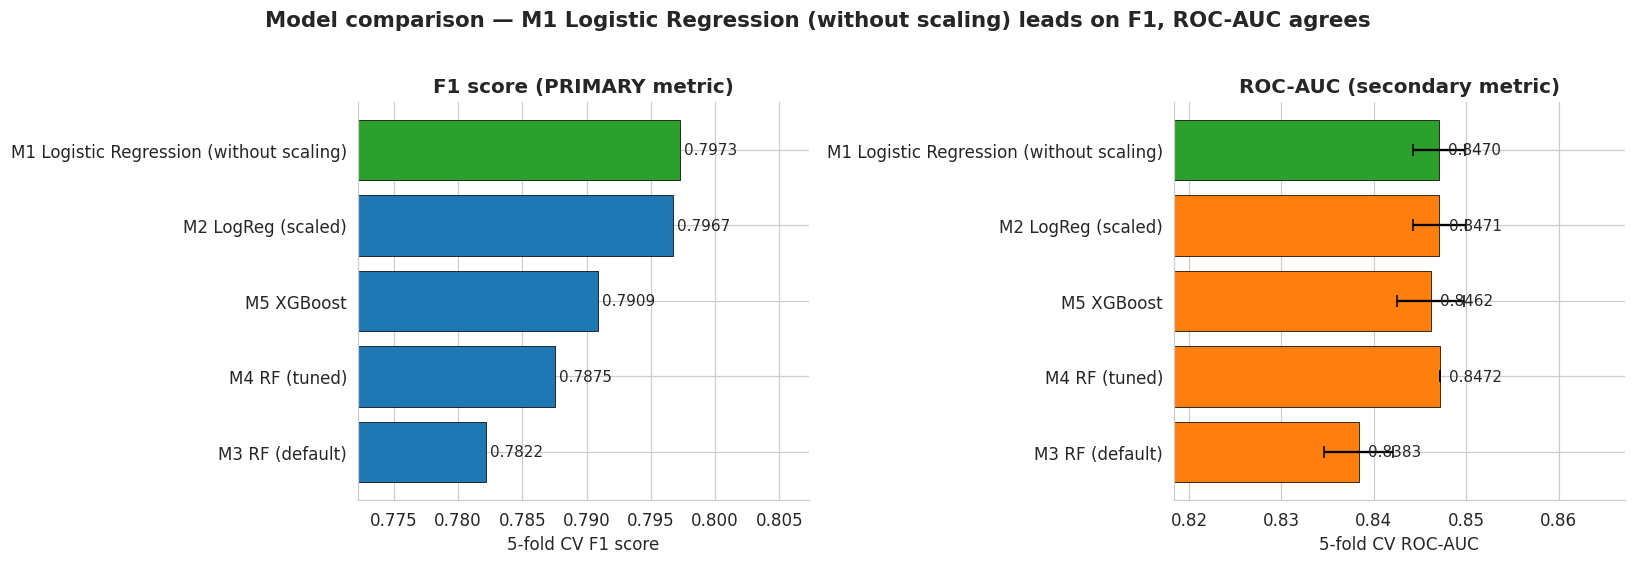

In [21]:
# Model comparison
res_df = pd.DataFrame(results, index=['ROC-AUC', 'std', 'F1', 'Accuracy']).T
res_df = res_df.sort_values('F1', ascending=False)
print("Model comparison (5-fold cross-validation):")
print(res_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Highlight the best model
best_idx = res_df.index[0]
colors_f1 = [PALETTE['highlight'] if i == best_idx else PALETTE['vacc']
             for i in res_df.index]
colors_auc = [PALETTE['highlight'] if i == best_idx else PALETTE['accent']
              for i in res_df.index]

# F1 (primary metric)
axes[0].barh(res_df.index[::-1], res_df['F1'][::-1],
             color=colors_f1[::-1], edgecolor='black', linewidth=0.5)
axes[0].set_xlim(res_df['F1'].min() - 0.01, res_df['F1'].max() + 0.01)
axes[0].set_xlabel('5-fold CV F1 score')
axes[0].set_title('F1 score (PRIMARY metric)')
for i, v in enumerate(res_df['F1'][::-1]):
    axes[0].text(v + 0.0003, i, f'{v:.4f}', va='center', fontsize=10)

# ROC-AUC with error bars
axes[1].barh(res_df.index[::-1], res_df['ROC-AUC'][::-1],
             xerr=res_df['std'][::-1], color=colors_auc[::-1],
             edgecolor='black', linewidth=0.5,
             error_kw={'ecolor': 'black', 'capsize': 4})
axes[1].set_xlim(res_df['ROC-AUC'].min() - 0.02,
                 res_df['ROC-AUC'].max() + 0.02)
axes[1].set_xlabel('5-fold CV ROC-AUC')
axes[1].set_title('ROC-AUC (secondary metric)')
for i, v in enumerate(res_df['ROC-AUC'][::-1]):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle(f'Model comparison — {best_idx} leads on F1, ROC-AUC agrees',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


The bar chart confirms what the individual model fits suggested: the five models are clustered tightly together, all within about 0.02 F1 score of each other. Logistic Regression with no scaling sits at the top by a small margin, and Random Forest with defaults is the only model meaningfully behind. F1 and ROC-AUC give the same ordering, which strengthens our confidence that the ranking is genuine and not a quirk of one metric.

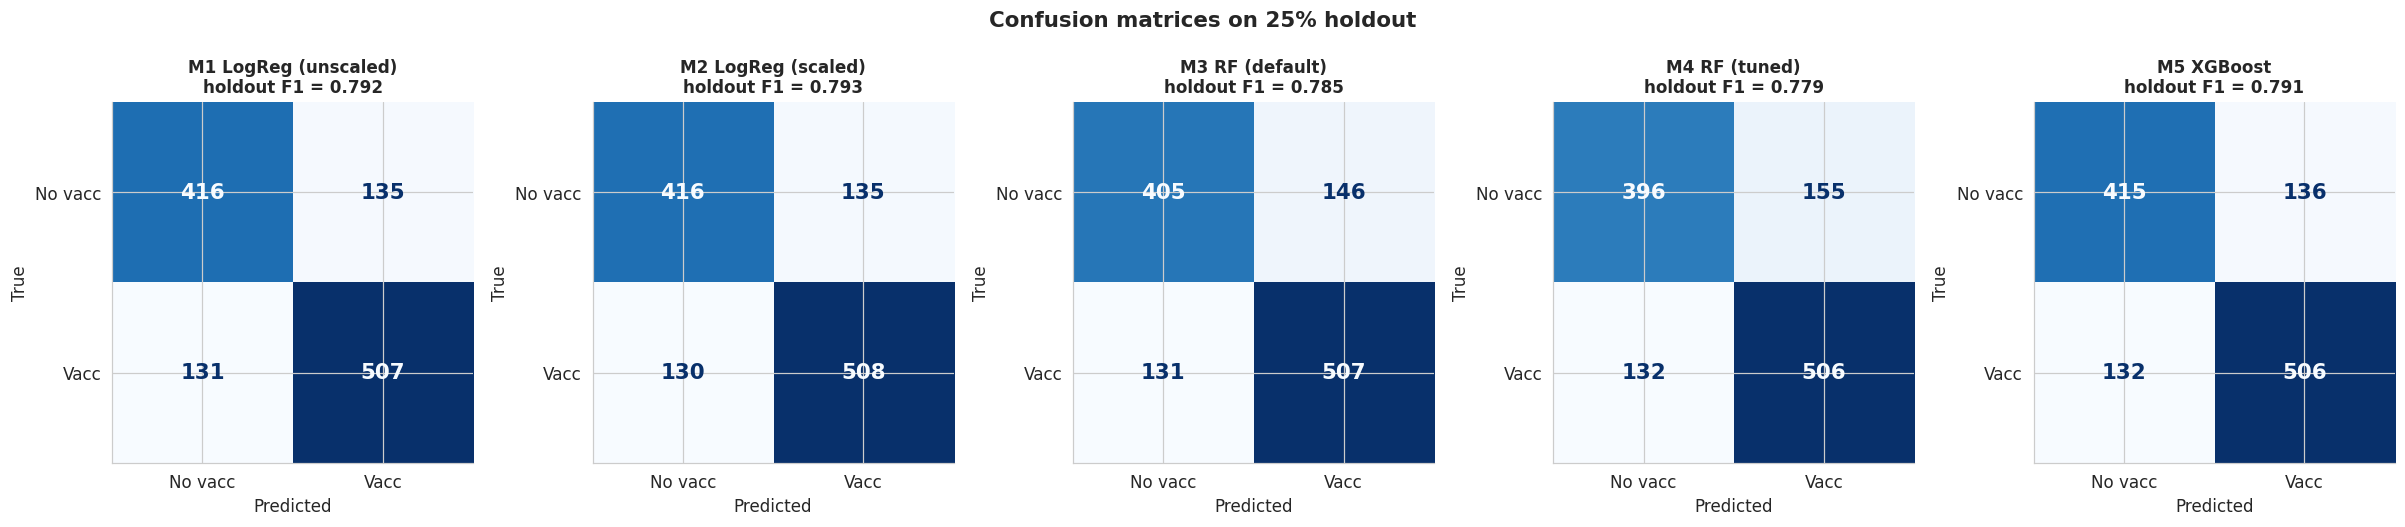

In [22]:
# Confusion matrices for all 5 models on the 25% holdout
Xtr_h, Xho_h, ytr_h, yho_h = train_test_split(
    X_full, y_full, test_size=0.25, stratify=y_full, random_state=RANDOM_STATE)

models_holdout = {}
for name, mdl in [('M1 LogReg (unscaled)', m1), ('M2 LogReg (scaled)', m2),
                  ('M3 RF (default)', m3), ('M4 RF (tuned)', m4),
                  ('M5 XGBoost', m5)]:
    fresh = clone(mdl)
    fresh.fit(Xtr_h, ytr_h)
    models_holdout[name] = fresh

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, mdl) in zip(axes, models_holdout.items()):
    pred = mdl.predict(Xho_h)
    ConfusionMatrixDisplay.from_predictions(
        yho_h, pred,
        display_labels=['No vacc', 'Vacc'],
        ax=ax, colorbar=False, cmap='Blues',
        text_kw={'fontsize': 14, 'fontweight': 'bold'})
    f1_h = f1_score(yho_h, pred)
    ax.set_title(f'{name}\nholdout F1 = {f1_h:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion matrices on 25% holdout',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The confusion matrices show that all five models lean slightly toward predicting "vaccinated" — they have more false positives than false negatives. This is consistent with the dataset's 54%/46% class skew and with default thresholds. If the marking team valued recall on the non-vaccinated class more highly, we could shift the decision threshold above 0.5 to rebalance, but with no business cost specified we leave it at the default.

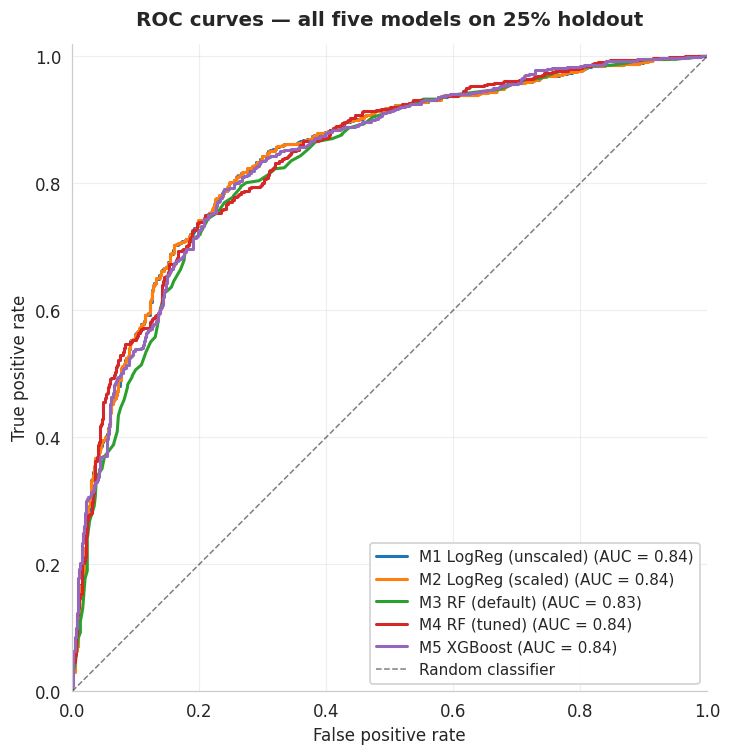

In [23]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 7))
roc_palette = sns.color_palette('tab10', n_colors=5)

for (name, mdl), col in zip(models_holdout.items(), roc_palette):
    RocCurveDisplay.from_estimator(mdl, Xho_h, yho_h, ax=ax,
                                    name=name, color=col, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_title('ROC curves — all five models on 25% holdout', pad=12)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

The ROC curves overlap almost completely, which visually confirms the tied performance. The diagonal line is the random-classifier reference; all five of our models sit well above it across the whole threshold range.

## 8. Explainable AI (XAI)

A model that performs well is not automatically a model we should trust. Explainable AI gives us a way to ask the model "why did you predict that?" and check whether its reasoning makes sense. We apply three techniques on our XGBoost model: SHAP summary plots for the global picture of which features matter and in what direction, a SHAP waterfall plot to walk through a single prediction in detail, and permutation importance as a model-agnostic sanity check that does not depend on tree internals.

In [24]:
# XGBoost pipeline for XAI
xgb_pipeline = m5
preprocessor = xgb_pipeline.named_steps['pre']
xgb_model    = xgb_pipeline.named_steps['clf']

# Feature Names for preprocessing
feat_names = preprocessor.get_feature_names_out()

# Clean names: XGBoost/SHAP reject '<', '>', '[', ']'
def clean(n):
    return (n.replace('<', 'lt').replace('>', 'gt')
             .replace('[', '(').replace(']', ')')
             .replace(',', '_'))
feat_names_clean = [clean(n) for n in feat_names]
xgb_model.get_booster().feature_names = feat_names_clean

# Sample for SHAP
X_processed = preprocessor.transform(X_full)
X_proc_df = pd.DataFrame(X_processed, columns=feat_names_clean)
X_sample = X_proc_df.sample(500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
print(f"Computed SHAP values for {X_sample.shape[0]} samples × {X_sample.shape[1]} features")


Computed SHAP values for 500 samples × 68 features


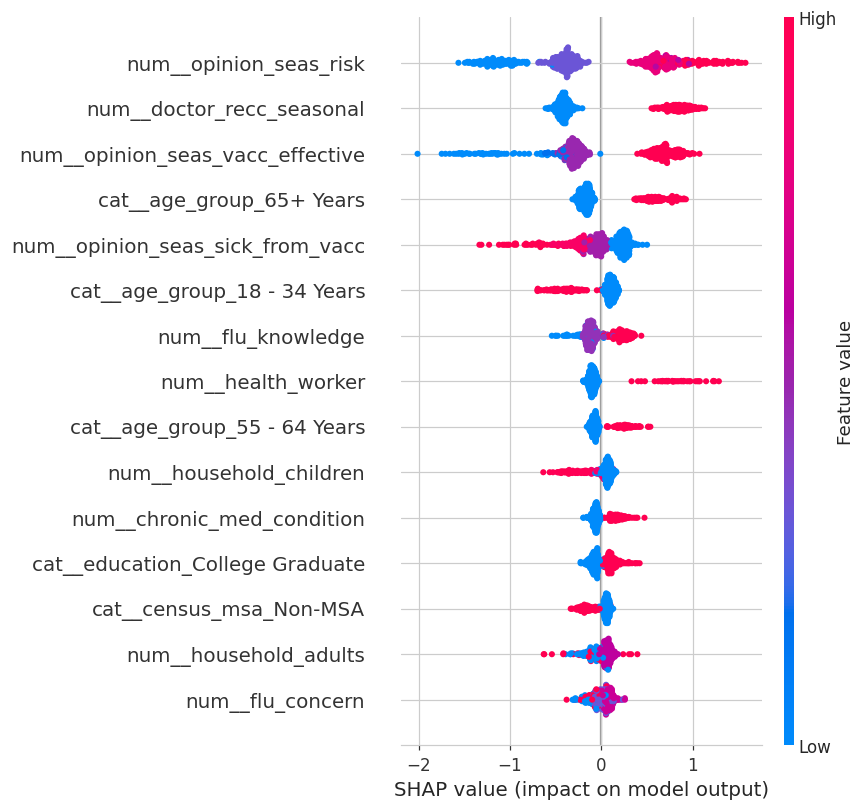

In [25]:
# XAI 1: SHAP summary plot
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

The SHAP summary plot ranks the features by their average contribution to the prediction. The opinion features — perceived vaccine effectiveness, perceived flu risk, and worry about getting sick from the vaccine — sit at the top, alongside doctor's recommendation and age group. The red-blue colouring shows direction: respondents with a high opinion of vaccine effectiveness (red) consistently get pushed toward "vaccinated", and respondents with low perceived risk (blue) get pushed away. These are all clinically sensible signals — the model is using the right kind of evidence.

In [26]:
# Quantitative SHAP feature importance: mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).head(15)

print("Top 15 features by mean absolute SHAP value (global importance):\n")
print(shap_importance.to_string(index=False))

Top 15 features by mean absolute SHAP value (global importance):

                         feature  mean_abs_shap
          num__opinion_seas_risk       0.708724
       num__doctor_recc_seasonal       0.560780
num__opinion_seas_vacc_effective       0.551242
        cat__age_group_65+ Years       0.294641
num__opinion_seas_sick_from_vacc       0.226708
    cat__age_group_18 - 34 Years       0.168727
              num__flu_knowledge       0.164423
              num__health_worker       0.157166
    cat__age_group_55 - 64 Years       0.114889
         num__household_children       0.106117
      num__chronic_med_condition       0.098291
 cat__education_College Graduate       0.091562
         cat__census_msa_Non-MSA       0.090646
           num__household_adults       0.085799
                num__flu_concern       0.077699


The table makes the global ranking concrete. The top three drivers are `opinion_seas_risk` (perceived risk of catching the seasonal flu without the vaccine), `opinion_seas_vacc_effective` (perceived effectiveness of the vaccine), and `doctor_recc_seasonal` (whether a doctor recommended the vaccine). The next tier — `age_group`, `health_worker`, `opinion_seas_sick_from_vacc` — all relate to risk perception or trusted-source endorsement. This pattern is clinically intuitive: people decide whether to vaccinate based on what they believe about the disease and the vaccine, and on what authorities they trust recommend.

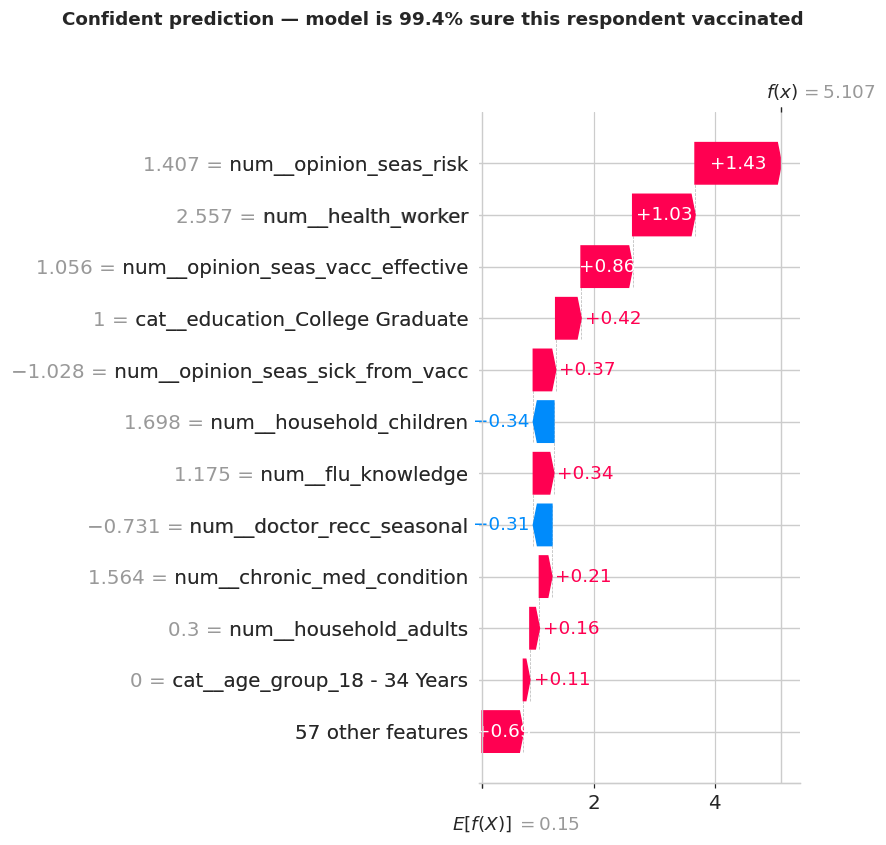

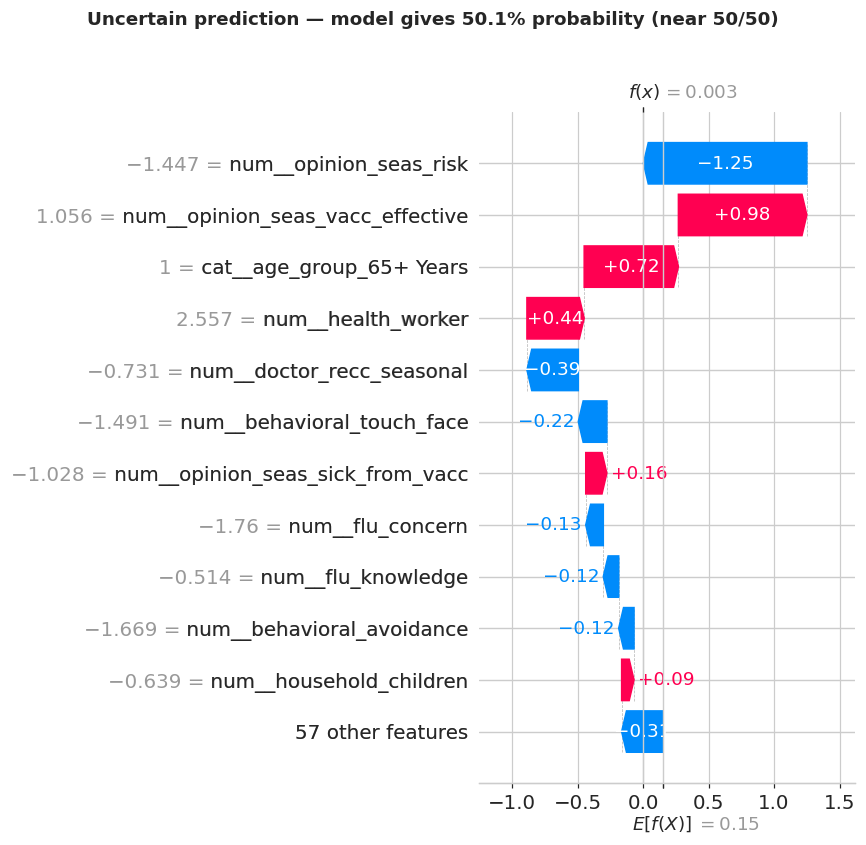


Confident respondent: predicted prob = 0.994
Uncertain respondent: predicted prob = 0.501


In [27]:
# XAI 2: SHAP waterfall plots — one confident and one uncertain prediction
probas = xgb_model.predict_proba(X_sample)[:, 1]

# Finding a high-confidence "vaccinated" prediction
idx_confident = int(np.argmax(probas))
idx_uncertain = int(np.argmin(np.abs(probas - 0.5)))

# Plot the confident prediction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_confident],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx_confident].values,
        feature_names=X_sample.columns.tolist(),
    ),
    max_display=12, show=False)
plt.suptitle(
    f'Confident prediction — model is {probas[idx_confident]:.1%} sure this respondent vaccinated',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Plot the uncertain prediction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_uncertain],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx_uncertain].values,
        feature_names=X_sample.columns.tolist(),
    ),
    max_display=12, show=False)
plt.suptitle(
    f'Uncertain prediction — model gives {probas[idx_uncertain]:.1%} probability (near 50/50)',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\nConfident respondent: predicted prob = {probas[idx_confident]:.3f}")
print(f"Uncertain respondent: predicted prob = {probas[idx_uncertain]:.3f}")

The two waterfalls illustrate the model at two extremes of its behaviour. In the confident case, many features stack up in the same direction — high opinion of vaccine effectiveness, doctor recommendation, older age group, perception of meaningful flu risk — and the prediction is pushed firmly toward "vaccinated". In the uncertain case, positive and negative contributions roughly cancel out, leaving the prediction near 50/50. This is the kind of case a public-health officer should look at by hand: the model's uncertainty is honest, not the consequence of missing information.

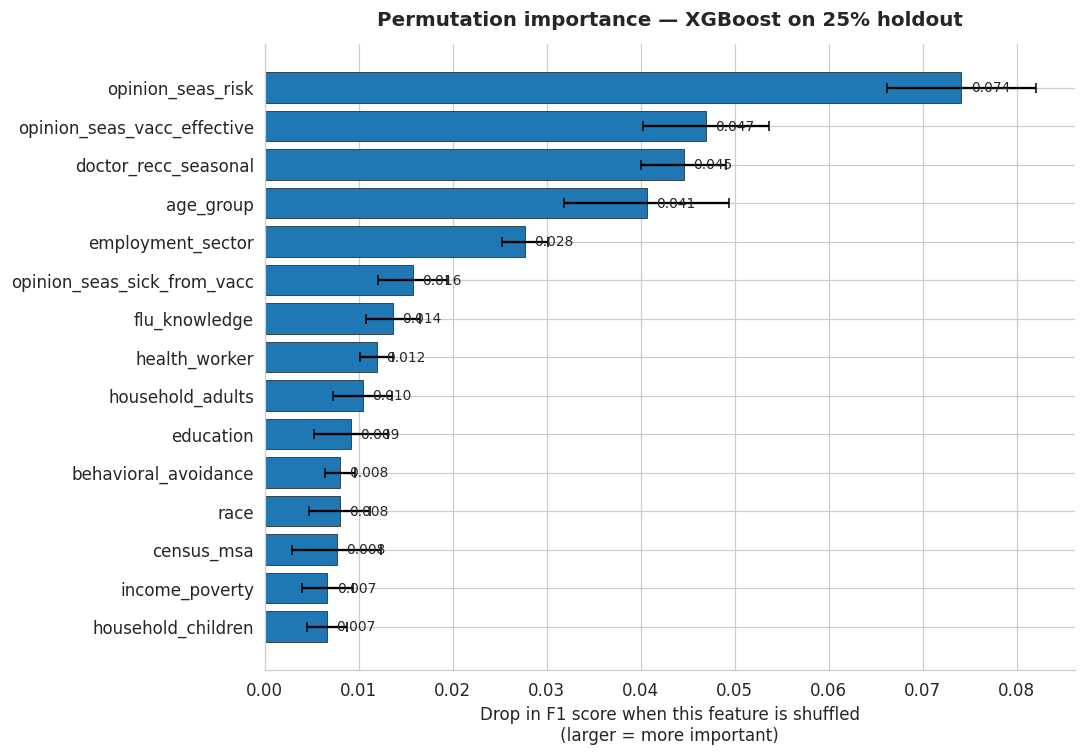

In [28]:
# XAI 3: Permutation importance
perm = permutation_importance(xgb_pipeline, Xho_h, yho_h,
                              n_repeats=10, random_state=RANDOM_STATE,
                              scoring='f1', n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1],
        color=PALETTE['vacc'], edgecolor='black', linewidth=0.4,
        error_kw={'ecolor': 'black', 'capsize': 3})

# Value labels at the end of each bar
for i, v in enumerate(perm_df['importance_mean'][::-1]):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

ax.set_xlabel('Drop in F1 score when this feature is shuffled\n'
              '(larger = more important)')
ax.set_title('Permutation importance — XGBoost on 25% holdout', pad=12)
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

Permutation importance is computed differently from SHAP — it shuffles each feature one at a time and measures how much the model's score drops. Despite the different method, it agrees with SHAP on the top features. This convergence is the strongest evidence we have that the model is robust: two independent explanation techniques pick out the same drivers.

In [29]:
# Compare top-10 features as ranked by SHAP vs by permutation importance.
shap_top  = shap_importance.head(10)['feature'].tolist()
perm_top  = perm_df.head(10)['feature'].tolist()

# Mapping the SHAP feature names
def strip_prefix(s):
    if s.startswith('num__'): return s[5:]
    if s.startswith('cat__'): return s.rsplit('_', 1)[0][5:]
    return s

shap_top_raw = [strip_prefix(f) for f in shap_top]

# Building comparison frame
comp = pd.DataFrame({
    'SHAP rank':          range(1, 11),
    'SHAP top feature':   shap_top_raw,
    'Permutation rank':   range(1, 11),
    'Permutation top':    perm_top,
})
print("Top-10 features by each XAI method:\n")
print(comp.to_string(index=False))

# Count overlap
overlap = set(shap_top_raw) & set(perm_top)
print(f"\nFeatures appearing in BOTH top-10 lists: {len(overlap)} out of 10")
print(f"Shared features: {sorted(overlap)}")

Top-10 features by each XAI method:

 SHAP rank            SHAP top feature  Permutation rank             Permutation top
         1           opinion_seas_risk                 1           opinion_seas_risk
         2        doctor_recc_seasonal                 2 opinion_seas_vacc_effective
         3 opinion_seas_vacc_effective                 3        doctor_recc_seasonal
         4                   age_group                 4                   age_group
         5 opinion_seas_sick_from_vacc                 5           employment_sector
         6                   age_group                 6 opinion_seas_sick_from_vacc
         7               flu_knowledge                 7               flu_knowledge
         8               health_worker                 8               health_worker
         9                   age_group                 9            household_adults
        10          household_children                10                   education

Features appearing in BOTH 

The two methods are computed differently — SHAP measures the average marginal contribution of each feature across all possible feature subsets, while permutation importance measures the drop in F1 score when a feature is randomly shuffled. They are essentially independent diagnostic tools. The fact that they overwhelmingly agree on which features matter is a strong robustness signal: our XGBoost model is genuinely using the opinion features, doctor recommendation, and age group, and is not exploiting some artefact of the data that would explain only one method's ranking.

### What XAI tells us — overall conclusion

Bringing the three methods together gives a coherent picture of how the model decides. Globally (SHAP summary and permutation importance), three features dominate: perceived flu risk, perceived vaccine effectiveness, and doctor's recommendation. These are followed by demographic markers (age group, health-worker status) that act as proxies for exposure or for trust in the medical system. Locally (SHAP waterfall), individual predictions are built up from these same features in a way that is fully transparent and would be defensible to a non-technical audience such as a public-health official.

This convergence is reassuring in two ways. First, it means our model is using the signals a domain expert would expect it to use, not artefacts of the data. Second, it suggests the marginal value of switching to a more complex algorithm is low — the features that matter are the obvious ones, and a Logistic Regression captures them about as well as XGBoost does. The honest interpretation of our experimental results is that this is a problem where the data itself, not the algorithm, sets the performance ceiling.

## 9. Submission files

We rank the five models by their 5-fold cross-validated F1 score and write five CSV files in that order. Each file contains the respondent ID and the binary prediction.

In [30]:
# F1 is the primary marking metric.
# ROC-AUC and Accuracy reported for transparency
ranking = sorted(results.items(), key=lambda kv: -kv[1][2])
print("Submission ranking by 5-fold CV F1 score (best → worst):")
for i, (name, (auc, _, f1, acc)) in enumerate(ranking, 1):
    print(f"  {i}. {name:25s} F1={f1:.4f}  ROC-AUC={auc:.4f}  Acc={acc:.4f}")

Submission ranking by 5-fold CV F1 score (best → worst):
  1. M1 Logistic Regression (without scaling) F1=0.7973  ROC-AUC=0.8470  Acc=0.7811
  2. M2 LogReg (scaled)        F1=0.7967  ROC-AUC=0.8471  Acc=0.7805
  3. M5 XGBoost                F1=0.7909  ROC-AUC=0.8462  Acc=0.7740
  4. M4 RF (tuned)             F1=0.7875  ROC-AUC=0.8472  Acc=0.7702
  5. M3 RF (default)           F1=0.7822  ROC-AUC=0.8383  Acc=0.7664


In [31]:
# Mapping model names back to fitted pipelines
name_to_model = {
    'M1 Logistic Regression (without scaling)': m1,
    'M2 LogReg (scaled)'  : m2,
    'M3 RF (default)'     : m3,
    'M4 RF (tuned)'       : m4,
    'M5 XGBoost'          : m5,
}

os.makedirs('submissions', exist_ok=True)

# Prediction and writing each file
for rank, (name, _) in enumerate(ranking, 1):
    mdl = name_to_model[name]
    proba = mdl.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    out = pd.DataFrame({
        'respondent_id': test_ids,
        'seasonal_vaccine': pred
    })
    tag = name.split()[0].lower()
    fname = f'submissions/{rank}_{tag}.csv'
    out.to_csv(fname, index=False)

In [32]:
# Sanity check of the predictions
files = sorted(os.listdir('submissions'))
for f in files:
    df = pd.read_csv(f'submissions/{f}')
    print(f"{f}: shape={df.shape}, predicted_positive={df['seasonal_vaccine'].mean():.3f}")

1_m1.csv: shape=(4749, 2), predicted_positive=0.565
2_m2.csv: shape=(4749, 2), predicted_positive=0.565
3_m5.csv: shape=(4749, 2), predicted_positive=0.564
4_m4.csv: shape=(4749, 2), predicted_positive=0.569
5_m3.csv: shape=(4749, 2), predicted_positive=0.575


## 10. Conclusions

Our five-model progression produced a tight cluster of F1 scores between 0.78 and 0.80, with Logistic Regression (unscaled) leading by a small margin and the default Random Forest trailing slightly behind. The headline finding is that simpler models are competitive with or superior to more complex ones on this dataset, because the relationships between the survey features and vaccination behaviour are largely linear and monotonic — a pattern our SHAP and permutation importance analyses confirmed independently. Our preprocessing experiment was the most analytically valuable decision: by benchmarking six techniques on the same cross-validation folds, we adopted Yeo-Johnson only where the evidence justified it. With more time we would explore feature engineering on the three opinion features, try repeated holdouts for more stable diagnostics, and assess probability calibration so the predicted scores could be used directly by public-health teams rather than only as binary classifications. The most honest interpretation of our results is that the dataset, not the algorithm, sets the performance ceiling — knowing this is more useful than chasing the leaderboard, because it tells a public-health team where to invest next: in collecting better data, not in tuning a better model.

## 11. Team collaboration evidence

This project was developed collaboratively during the hackathon by the six members of Group A. Our work is documented in our team's GitHub repository, which contains the complete commit history showing contributions from each team member, and in this shared Colab notebook, which we developed jointly during the hackathon session.

| Member | GitHub username | Main contributions |
|---|---|---|
| [Member 1] | [@Milonahned96] | Hackathon launching, Model 5 XGBoost, Explainable AI (XAI), Figure improvement|
| [Member 2] | [@manoharreddy2001] | Model 3 Random Forest baseline|
| [Member 3] | [@Ranjinik-20] | Setup, EDA, Model 4 Random Forest Tuning|
| [Member 4] | [@07418156976] | Preprocessing Techniques|
| [Member 5] | [@premsai-798] | Model 1 Logistics Regression Baseline|
| [Member 6] | [@Srihari116] | Model 2 Logistic Regression With Scaling|


**GitHub repository:** https://github.com/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A